Final Project


Before you begin


Create a new notebook in your working directory. Copy these instructions as plain text into the first cell. That way you will not have to flip back and forth between your notebook and this page.
Make sure that the astropy and sep packages are installed on your machine by launching a command window and running:
pip install astropy
pip install sep
Download the file hlsp_hudf12_hst_wfc3ir_udfmain_f105w_v1.0_drz.fits from this archiveLinks to an external site. and save it to your working directory (the same directory that has your notebook).


The task


Follow the tutorial found at https://sep.readthedocs.io/en/stable/tutorial.htmlLinks to an external site., applying it to the data file you just downloaded. For best results (and for full credit) follow these suggestions: 

Gradually copy the code from the tutorial into your own jupyter notebook, run and debug until you successfully replicate the tutorial. Do not try to copy and run it all at once, it's not going to work! You need to debug as you go.
Use markdown to break the notebook into sections, as in the tutorial.
Finish your notebook by answering the following questions, using a combination of text and code directly in the notebook. (Terms like sources and fluxes will gradually become clear as you progress through the tutorial. You are not expected to fully understand all the details.) 
1) How many sources (stars) do you find in the data? Histogram their fluxes.
2) What are the mean, median, and standard deviation of the distribution of fluxes.
3) What is the largest outlier in the distribution; how many standard deviations is it away from the mean?

Tutorial


This tutorial shows the basic steps of using SEP to detect objects in an image and perform some basic aperture photometry.

Here, we use the fitsio package, just to read the test image, but you can also use astropy.io.fits for this purpose (or any other FITS reader).

In [1]:
import numpy as np
import sep

In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = [10., 8.]


First, we’ll read an example image from a FITS file and display it, just to show what we’re dealing with. The example image is just 256 x 256 pixels.

In [3]:
# read image into standard 2-d numpy array
data = fits.getdata("hlsp_hudf12_hst_wfc3ir_udfmain_f105w_v1.0_drz.fits")

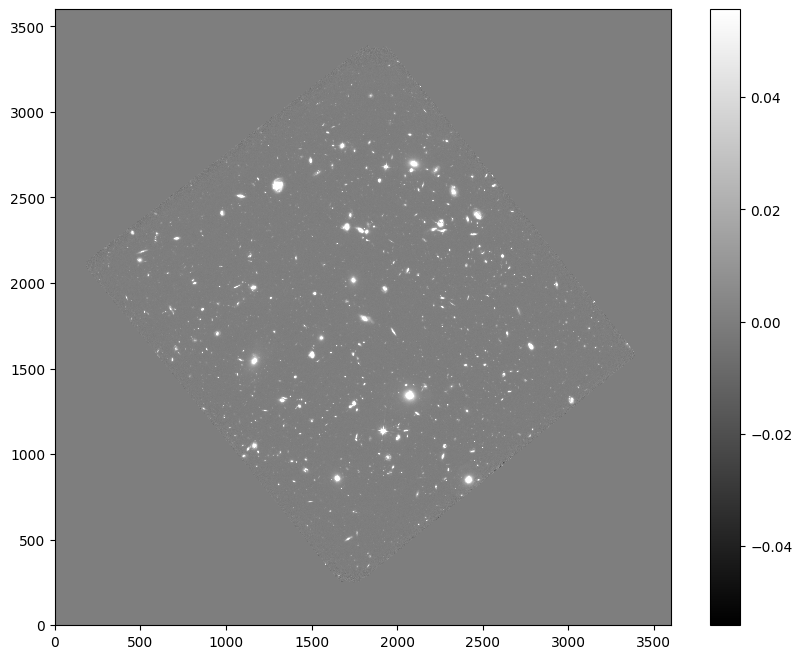

In [4]:
# show the image
m, s = np.mean(data), np.std(data)
plt.imshow(data, interpolation='nearest', cmap='gray', vmin=m-s, vmax=m+s, origin='lower')
plt.colorbar()

Background subtraction


Most optical/IR data must be background subtracted before sources can be detected. In SEP, background estimation and source detection are two separate steps.

In [5]:
# measure a spatially varying background on the image
data = data.astype(data.dtype.newbyteorder('=')) #added because error message said put this before the next statement
bkg = sep.Background(data)

There are various options for controlling the box size used in estimating the background. It is also possible to mask pixels. For example:

bkg = sep.Background(data, mask=mask, bw=64, bh=64, fw=3, fh=3)
See the reference section for descriptions of these parameters.

This returns an Background object that holds information on the spatially varying background and spatially varying background noise level. We can now do various things with this Background object:



In [6]:
# get a "global" mean and noise of the image background:
print(bkg.globalback)
print(bkg.globalrms)

0.0
0.0005398219218477607


In [7]:
# evaluate background as 2-d array, same size as original image
bkg_image = bkg.back()
# bkg_image = np.array(bkg) # equivalent to above

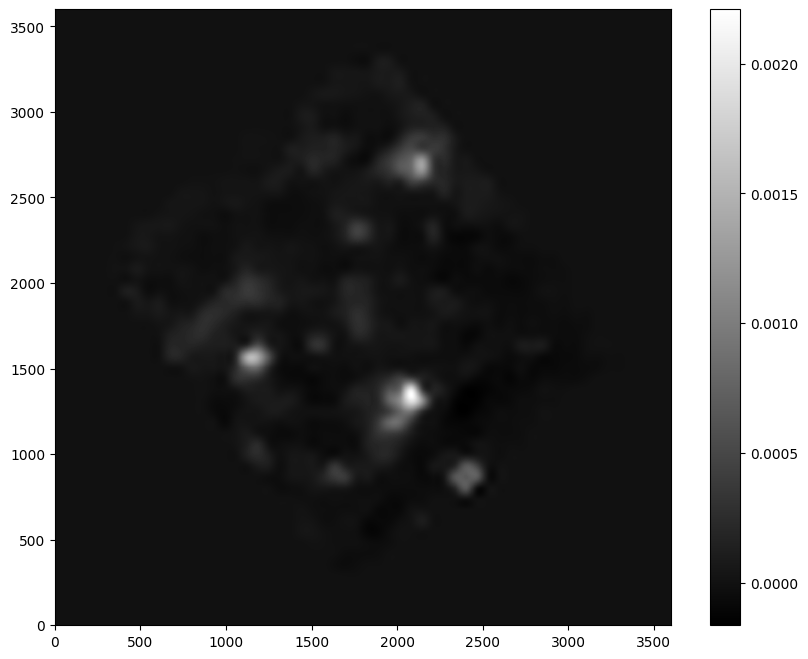

In [8]:
# show the background
plt.imshow(bkg_image, interpolation='nearest', cmap='gray', origin='lower')
plt.colorbar()

In [9]:
# subtract the background
data_sub = data - bkg

One can also subtract the background from the data array in-place by doing bkg.subfrom(data).

Object detection


Now that we’ve subtracted the background, we can run object detection on the background-subtracted data. You can see the background noise level is pretty flat. So here we’re setting the detection threshold to be a constant value of 
 where 
 is the global background RMS.

In [11]:
objects = sep.extract(data_sub, 1.5, err=bkg.globalrms) #ingrasing num lowers num objects

sep.extract has many options for controlling detection threshold, pixel masking, filtering, and object deblending. See the reference documentation for details.

objects is a NumPy structured array with many fields.

In [12]:
# how many objects were detected
num_stars = len(objects)
print(num_stars)

8633


objects['x'] and objects['y'] will give the centroid coordinates of the objects. Just to check where the detected objects are, we’ll over-plot the object coordinates with some basic shape parameters on the image:

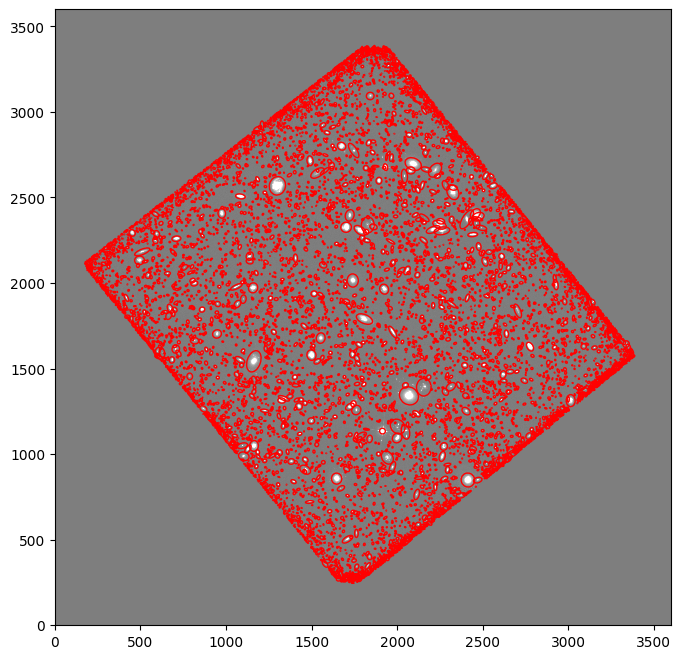

In [13]:
from matplotlib.patches import Ellipse

# plot background-subtracted image
fig, ax = plt.subplots()
m, s = np.mean(data_sub), np.std(data_sub)
im = ax.imshow(data_sub, interpolation='nearest', cmap='gray',
               vmin=m-s, vmax=m+s, origin='lower')

# plot an ellipse for each object
for i in range(len(objects)):
    e = Ellipse(xy=(objects['x'][i], objects['y'][i]),
                width=6*objects['a'][i],
                height=6*objects['b'][i],
                angle=objects['theta'][i] * 180. / np.pi)
    e.set_facecolor('none')
    e.set_edgecolor('red')
    ax.add_artist(e)

objects has many other fields, giving information such as second moments, and peak pixel positions and values. See the reference documentation for sep.extract for descriptions of these fields. You can see the available fields:

In [14]:
# available fields
objects.dtype.names

('thresh',
 'npix',
 'tnpix',
 'xmin',
 'xmax',
 'ymin',
 'ymax',
 'x',
 'y',
 'x2',
 'y2',
 'xy',
 'errx2',
 'erry2',
 'errxy',
 'a',
 'b',
 'theta',
 'cxx',
 'cyy',
 'cxy',
 'cflux',
 'flux',
 'cpeak',
 'peak',
 'xcpeak',
 'ycpeak',
 'xpeak',
 'ypeak',
 'flag')

Aperture photometry


Finally, we’ll perform simple circular aperture photometry with a 3 pixel radius at the locations of the objects:

In [15]:
flux, fluxerr, flag = sep.sum_circle(data_sub, objects['x'], objects['y'],
                                     3.0, err=bkg.globalrms, gain=1.0)


flux, fluxerr and flag are all 1-d arrays with one entry per object.

In [16]:
# show the first 10 objects results:
for i in range(10):
    print("object {:d}: flux = {:f} +/- {:f}".format(i, flux[i], fluxerr[i]))

object 0: flux = 0.031282 +/- 0.176890
object 1: flux = 0.031018 +/- 0.176142
object 2: flux = -0.024388 +/- 0.002883
object 3: flux = 0.001947 +/- 0.044219
object 4: flux = 0.012457 +/- 0.111649
object 5: flux = -0.011228 +/- 0.002875
object 6: flux = 0.029368 +/- 0.171394
object 7: flux = -0.009126 +/- 0.002875
object 8: flux = 0.048023 +/- 0.219161
object 9: flux = 0.027840 +/- 0.166877


# Final Questions to Answer



Question 1


I found 8645 stars

Text(0, 0.5, 'number of sources')

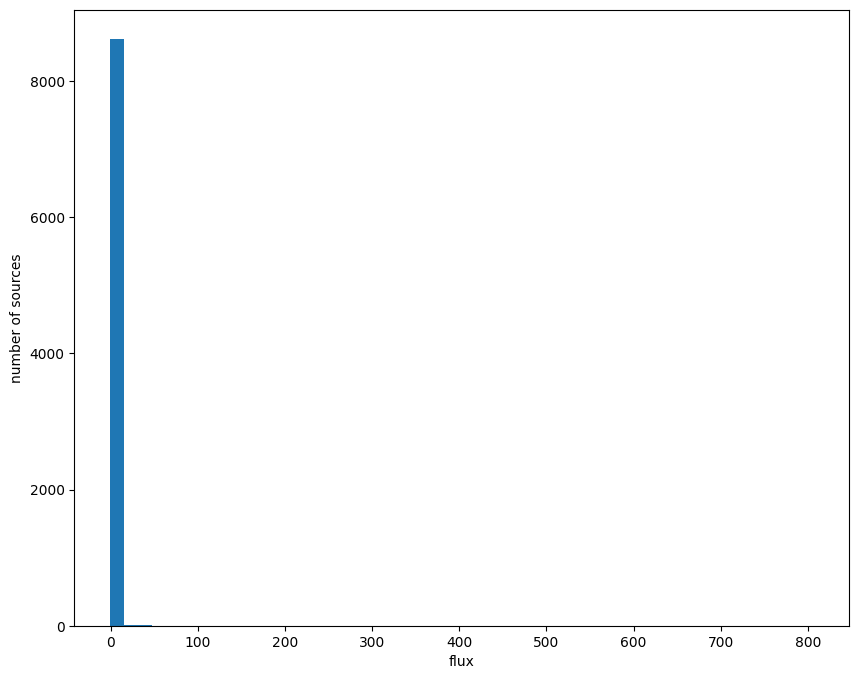

In [17]:
plt.hist(flux,bins =50)
plt.xlabel('flux')
plt.ylabel('number of sources')

Question 2

In [18]:
mean = np.mean(flux)
median = np.median(flux)
standard_dev = np.std(flux)

print(f"Mean: {mean}")
print(f"Median: {median}")
print(f"Standard Deviation: {standard_dev}")

Mean: 0.36213521654158226
Median: 0.030976216696435587
Standard Deviation: 9.247269636606394


Question 3

In [19]:
lg_outlier = np.max(flux)
standard_devs = (lg_outlier - mean) / standard_dev
print(f"Largest outlier flux: {lg_outlier}")
print(f"Standard deviations from mean: {standard_devs}")

Largest outlier flux: 807.2972835731507
Standard deviations from mean: 87.26198976206581
